# **Set Up and Cleaning**

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df_raw = pd.read_csv('/content/drive/MyDrive/kickstarter.csv')


In [23]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   deadline          378661 non-null  object 
 5   launched          378661 non-null  object 
 6   pledged           378661 non-null  float64
 7   state             378661 non-null  object 
 8   backers           378661 non-null  int64  
 9   country           378661 non-null  object 
 10  usd_pledged_real  378661 non-null  float64
 11  usd_goal_real     378661 non-null  float64
dtypes: float64(3), int64(2), object(7)
memory usage: 34.7+ MB


In [24]:
#check duplicated
df_raw[df_raw.duplicated()==True]

,ID,name,category,main_category,deadline,launched,pledged,state,backers,country,usd_pledged_real,usd_goal_real


In [25]:
#check missing
print("Missing values per column:")
print(df_raw.isnull().sum())
missing_indices = df_raw[df_raw.isna().any(axis=1)].index
print(missing_indices)

Missing values per column:
ID                  0
name                4
category            0
main_category       0
deadline            0
launched            0
pledged             0
state               0
backers             0
country             0
usd_pledged_real    0
usd_goal_real       0
dtype: int64
Index([166851, 307234, 309991, 338931], dtype='int64')


In [26]:
df_cleaned = df_raw

In [27]:
df_cleaned['launched'] = pd.to_datetime(df_cleaned['launched'], infer_datetime_format=True)
df_cleaned['launched_year'] = df_cleaned['launched'].dt.year
df_cleaned['launched_month'] = df_cleaned['launched'].dt.month
df_cleaned['month_year'] = df_cleaned['launched'].dt.to_period('M')
df_cleaned

/tmp/ipykernel_8027/231013143.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_cleaned['launched'] = pd.to_datetime(df_cleaned['launched'], infer_datetime_format=True)
/tmp/ipykernel_8027/231013143.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_cleaned['launched'] = pd.to_datetime(df_cleaned['launched'], infer_datetime_format=True)


,ID,name,category,main_category,deadline,launched,pledged,state,backers,country,usd_pledged_real,usd_goal_real,launched_year,launched_month,month_year
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,10/9/15,2015-08-11 12:12:00,0.0,failed,0,GB,0.0,1533.95,2015,8,2015-08
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,11/1/17,2017-09-02 04:43:00,2421.0,failed,15,US,2421.0,30000.00,2017,9,2017-09
2,1000004038,Where is Hank?,Narrative Film,Film & Video,2/26/13,2013-01-12 00:20:00,220.0,failed,3,US,220.0,45000.00,2013,1,2013-01
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,4/16/12,2012-03-17 03:24:00,1.0,failed,1,US,1.0,5000.00,2012,3,2012-03
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,8/29/15,2015-07-04 08:35:00,1283.0,canceled,14,US,1283.0,19500.00,2015,7,2015-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378656,999976400,ChknTruk Nationwide Charity Drive 2014 (Canceled),Documentary,Film & Video,10/17/14,2014-09-17 02:35:00,25.0,canceled,1,US,25.0,50000.00,2014,9,2014-09
378657,999977640,The Tribe,Narrative Film,Film & Video,7/19/11,2011-06-22 03:35:00,155.0,failed,5,US,155.0,1500.00,2011,6,2011-06
378658,999986353,Walls of Remedy- New lesbian Romantic Comedy f...,Narrative Film,Film & Video,8/16/10,2010-07-01 19:40:00,20.0,failed,1,US,20.0,15000.00,2010,7,2010-07
378659,999987933,BioDefense Education Kit,Technology,Technology,2/13/16,2016-01-13 18:13:00,200.0,failed,6,US,200.0,15000.00,2016,1,2016-01


In [28]:
#check outlier
df_cleaned.describe()

,ID,launched,pledged,backers,usd_pledged_real,usd_goal_real,launched_year,launched_month
count,3.786610e+05,378661,3.786610e+05,378661.000000,3.786610e+05,3.786610e+05,378661.000000,378661.000000
mean,1.074731e+09,2014-09-29 10:18:05.989209088,9.682979e+03,105.617476,9.058924e+03,4.545440e+04,2014.249677,6.461550
min,5.971000e+03,2009-04-21 21:02:00,0.000000e+00,0.000000,0.000000e+00,1.000000e-02,2009.000000,1.000000
25%,5.382635e+08,2013-05-07 22:49:00,3.000000e+01,2.000000,3.100000e+01,2.000000e+03,2013.000000,4.000000
50%,1.075276e+09,2014-12-10 03:59:00,6.200000e+02,12.000000,6.243300e+02,5.500000e+03,2014.000000,7.000000
75%,1.610149e+09,2016-03-24 11:32:00,4.076000e+03,56.000000,4.050000e+03,1.550000e+04,2016.000000,9.000000
max,2.147476e+09,2070-01-01 01:00:00,2.033899e+07,219382.000000,2.033899e+07,1.663614e+08,2070.000000,12.000000
std,6.190862e+08,NaN,9.563601e+04,907.185035,9.097334e+04,1.152950e+06,1.938785,3.330133


In [29]:
df_cleaned['goal_range'] = df_cleaned['usd_goal_real'].apply(
    lambda x: 'Low goal' if x <= 5000 else ('Medium goal' if x <= 20000 else 'High goal')
)

In [30]:
# Create the mapping dictionary based on your image
country_map = {
    'AT': 'Austria', 'AU': 'Australia', 'BE': 'Belgium', 'CA': 'Canada',
    'CH': 'Switzerland', 'DE': 'Germany', 'DK': 'Denmark', 'ES': 'Spain',
    'FR': 'France', 'GB': 'United Kingdom', 'HK': 'Hong Kong', 'IE': 'Ireland',
    'IT': 'Italy', 'JP': 'Japan', 'LU': 'Luxembourg', 'MX': 'Mexico',
    'NL': 'Netherlands', 'NO': 'Norway', 'NZ': 'New Zealand', 'SE': 'Sweden',
    'SG': 'Singapore', 'N,0':'Unknown'
}

# Replace the values in the 'country' column
df_cleaned['country'] = df_cleaned['country'].map(country_map)
df_cleaned['country'].value_counts()

,count
country,
United Kingdom,33672
Canada,14756
Australia,7839
Germany,4171
France,2939
Italy,2878
Netherlands,2868
Spain,2276
Sweden,1757


In [31]:
df_cleaned['state'].value_counts()

,count
state,
failed,197719
successful,133956
canceled,38779
undefined,3562
live,2799
suspended,1846


In [32]:
df_cleaned[df_cleaned['name'].isnull()==True]

,ID,name,category,main_category,deadline,launched,pledged,state,backers,country,usd_pledged_real,usd_goal_real,launched_year,launched_month,month_year,goal_range
166851,1848699072,NaN,Narrative Film,Film & Video,2/29/12,2012-01-01 12:35:00,100.0,failed,1,NaN,100.00,200000.00,2012,1,2012-01,High goal
307234,634871725,NaN,Video Games,Games,1/6/13,2012-12-19 23:57:00,196.0,failed,12,United Kingdom,316.05,3224.97,2012,12,2012-12,Low goal
309991,648853978,NaN,Product Design,Design,7/18/16,2016-06-18 05:01:00,0.0,suspended,0,NaN,0.00,2500.00,2016,6,2016-06,Low goal
338931,796533179,NaN,Painting,Art,12/5/11,2011-11-06 23:55:00,220.0,failed,5,NaN,220.00,35000.00,2011,11,2011-11,High goal


In [33]:
ks_complete = df_cleaned[df_cleaned['state'].isin(['successful','failed'])]
ks_complete['goal_cat'] = ks_complete['usd_goal_real'].apply(
    lambda x: 'A' if x < 500 else ('B' if x < 5000 else ('C' if x <25000 else 'D'))
)
ks_complete_successful = ks_complete[ks_complete['state'] == 'successful']
ks_complete_successful['revenue'] = ks_complete['usd_pledged_real']*0.05
ks_complete_failed = ks_complete[ks_complete['state'] == 'failed']
ks_complete_failed['revenue'] = ks_complete['usd_pledged_real']*0.05

ks_complete['goal_cat'].value_counts()
ks_complete_successful[ks_complete_successful['goal_cat']== 'B']['revenue'].mean()

/tmp/ipykernel_8027/3887147302.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ks_complete['goal_cat'] = ks_complete['usd_goal_real'].apply(
/tmp/ipykernel_8027/3887147302.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ks_complete_successful['revenue'] = ks_complete['usd_pledged_real']*0.05
/tmp/ipykernel_8027/3887147302.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

np.float64(190.063077936176)

In [ ]:
ks_complete['revenue'] = ks_complete['state'].apply(
    lambda x: 0.05*ks_complete['usd_pledged_real'] if x =='successful' else 0
)

Text(0, 0.5, 'Percentage')

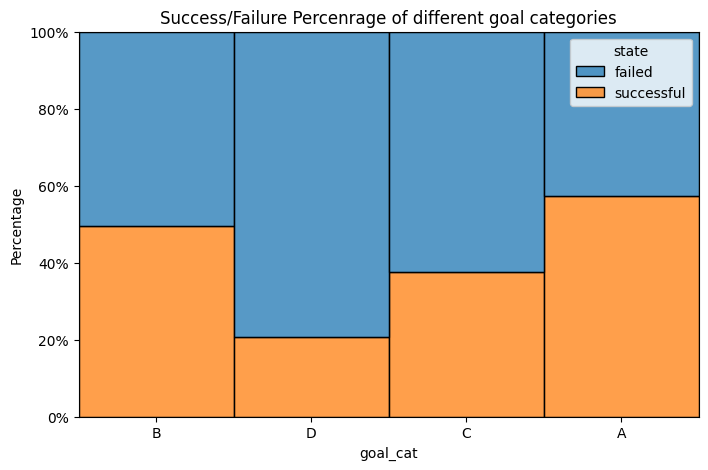

In [79]:
plt.figure(figsize=(8, 5))

ax = sns.histplot(data=ks_complete, x='goal_cat',
             binwidth=5,
             hue='state',
             multiple='fill')
plt.ticklabel_format(style='plain', axis='y')
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Success/Failure Percenrage of different goal categories')
plt.ylabel('Percentage')

In [61]:
ks_complete['pledge_prop'] = ks_complete['usd_pledged_real']/ks_complete['usd_goal_real']
ks_complete.groupby(['goal_cat','state']).agg({
    'pledge_prop':'mean',
    'ID':'count',
    'usd_goal_real' : 'mean',
    'usd_pledged_real': 'mean'
})

/tmp/ipykernel_8027/2110768897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ks_complete['pledge_prop'] = ks_complete['usd_pledged_real']/ks_complete['usd_goal_real']


pledge_prop     ID  usd_goal_real  usd_pledged_real
goal_cat state                                                          
A        failed         0.131510   8405     235.177209         32.419735
         successful    79.052176  11248     227.358725       1019.226203
B        failed         0.107853  64171    2171.551452        226.427260
         successful     2.044882  62641    2063.704630       3801.261559
C        failed         0.089674  80020   10806.428443        968.707699
         successful     2.040386  48227   10165.177943      21546.780955
D        failed         0.060175  45123  254521.843862       3740.662732
         successful     2.594147  11840   55313.937077     147649.776965

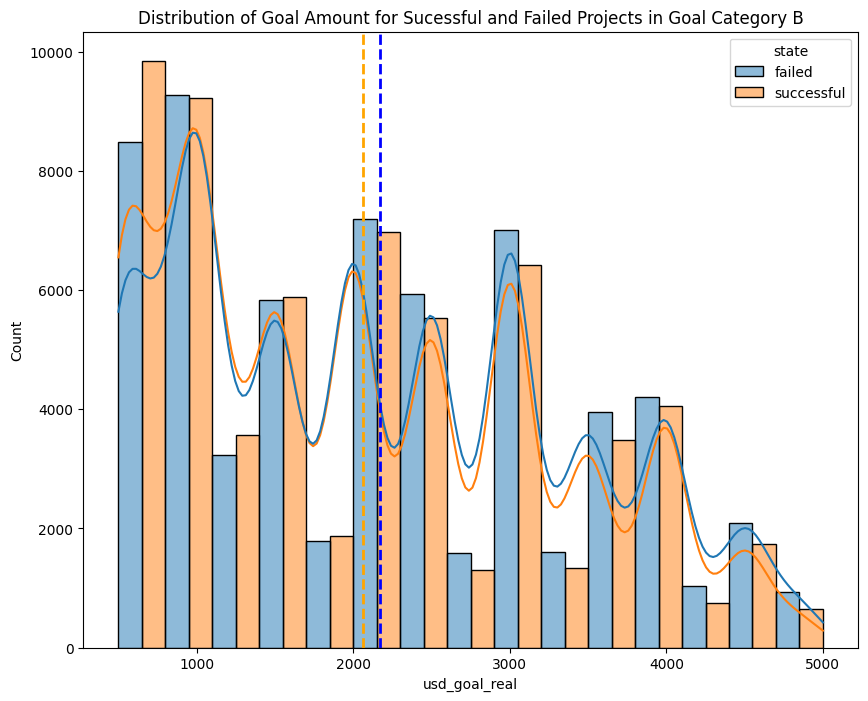

In [82]:
plt.figure(figsize=(10,8))
ks_complete_B = ks_complete[ks_complete['goal_cat'] == 'B']
hist=sns.histplot(data =ks_complete_B,
             x = 'usd_goal_real',
             hue = 'state',
             multiple = 'dodge',
             binwidth = 300,
             edgecolor='black',
             kde=True
             )
plt.title('Distribution of Goal Amount for Sucessful and Failed Projects in Goal Category B')
mean_su = ks_complete_B[ks_complete_B['state'] == 'successful']['usd_goal_real'].mean()
hist.axvline(x=mean_su, color='orange', linestyle='--', linewidth=2) # Add a vertical line at the mean

mean_fa = ks_complete_B[ks_complete_B['state'] == 'failed']['usd_goal_real'].mean()
hist.axvline(x=mean_fa, color='blue', linestyle='--', linewidth=2)


/tmp/ipykernel_8027/325472574.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ks_complete_B[numeric_features] = scaler.fit_transform(ks_complete_B[numeric_features])


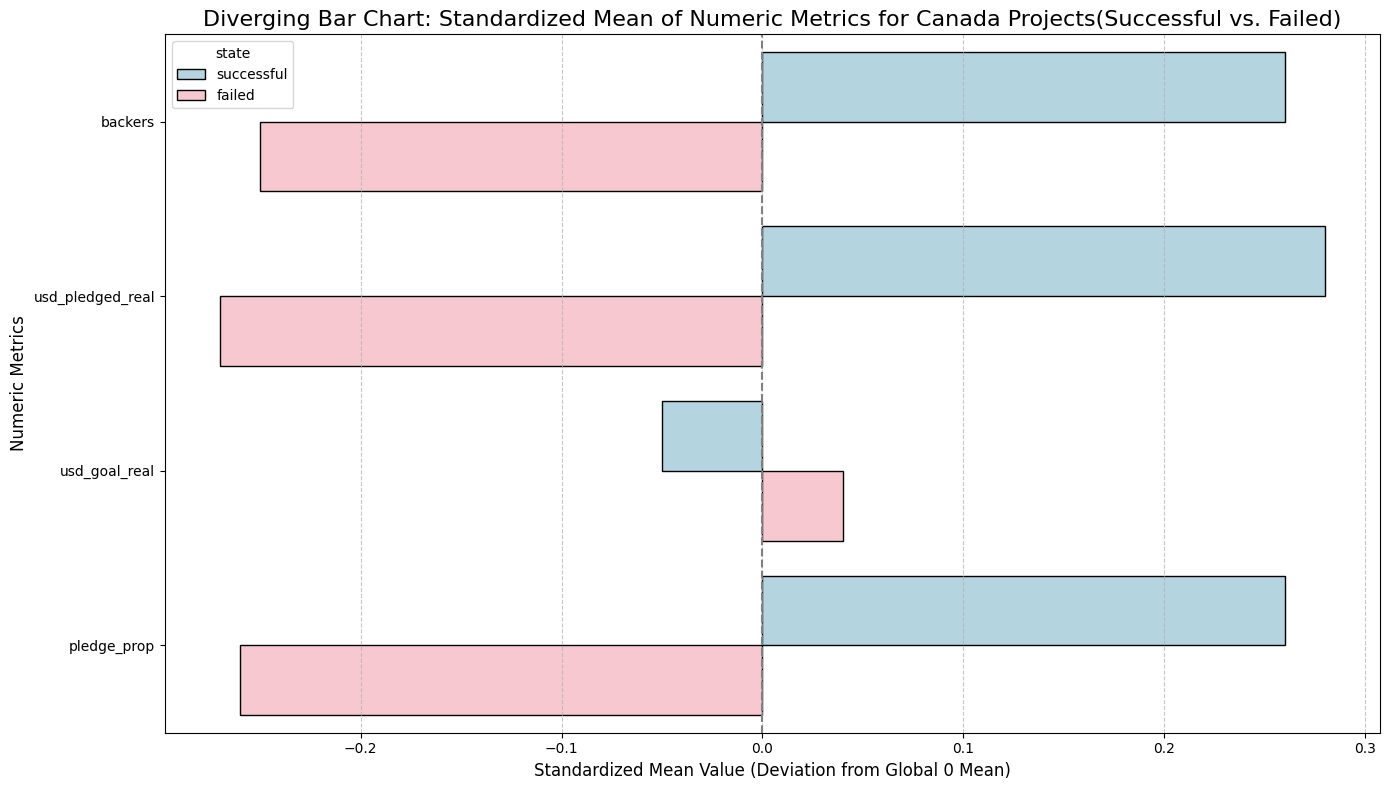

In [67]:
from sklearn.preprocessing import StandardScaler # for standardization

# Create a copy to avoid modifying the original df_pop directly for this operation
df_canada_normalized_features = df_cleaned[df_cleaned['country']=='Canada'].copy()

# Identify numeric columns (excluding 'track_popularity' and 'cat')
numeric_features = [
    'backers', 'usd_pledged_real', 'usd_goal_real','pledge_prop'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply normalization to each numeric feature across the entire DataFrame (regardless of cat)
ks_complete_B[numeric_features] = scaler.fit_transform(ks_complete_B[numeric_features])

# Now, calculate the mean of these globally normalized features grouped by 'cat'
# This will be our pop_feature equivalent for normalized data
df_for_diverging = ks_complete_B.groupby('state')[numeric_features].mean().round(2).T

# In this case, since data is standardized globally, the overall mean is approximately 0. We can directly use the 'high' and 'low' standardized means as their deviations from 0.

# Reset index to make 'feature' a regular column for plotting
df_for_diverging = df_for_diverging.reset_index().rename(columns={'index': 'metrics'})

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted_deviations = df_for_diverging.melt(
    id_vars=['metrics'],
    value_vars=['successful', 'failed'],
    var_name='state',
    value_name='deviation'
)

plt.figure(figsize=(14, 8)) # Adjust figure size for better readability

# Create the diverging bar chart
sns.barplot(
    data=df_melted_deviations,
    x='deviation',       # Deviation on the x-axis
    y='metrics',         # Features on the y-axis
    hue='state', # Differentiate 'high' and 'low' deviations
    palette={'successful': 'lightblue', 'failed': 'pink'},
    errorbar=None,       # No error bars as we're plotting calculated means
    dodge=True,           # Display bars for 'high' and 'low' side-by-side
    edgecolor='black'
)

# Add a vertical line at x=0 to emphasize deviations (which is now the global mean)
plt.axvline(0, color='gray', linestyle='--', linewidth=1.5)

plt.title('Diverging Bar Chart: Standardized Mean of Numeric Metrics for B Projects(Successful vs. Failed)', fontsize=16) # Updated title
plt.xlabel('Standardized Mean Value (Deviation from Global 0 Mean)', fontsize=12) # Updated label
plt.ylabel('Numeric Metrics', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# plt.legend(title='Popularity Category', bbox_to_anchor=(1.05, 1), loc='upper left') #if you wish to position the ledgend out of the chart
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8027/4245468872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ks_complete_B['deadline'] = pd.to_datetime(ks_complete_B['deadline'], format = 'mixed')
/tmp/ipykernel_8027/4245468872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ks_complete_B['year'] = ks_complete_B['deadline'].dt.year
/tmp/ipykernel_8027/4245468872.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

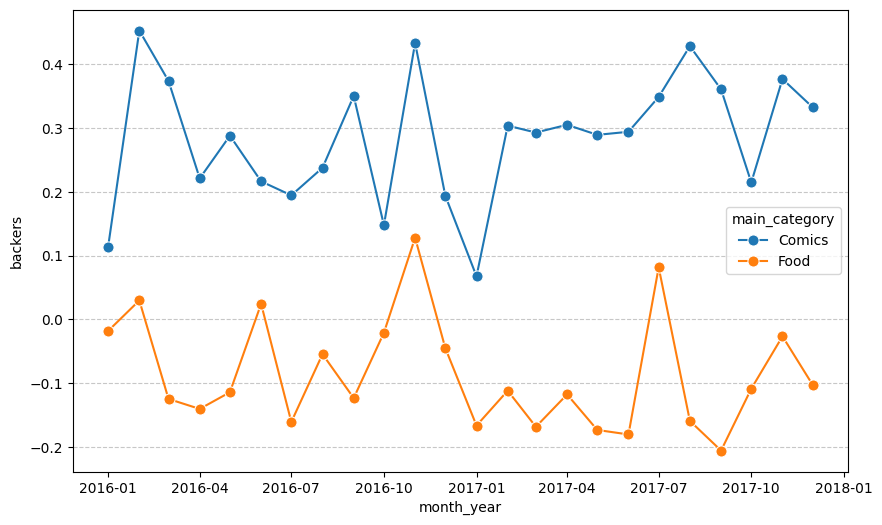

In [74]:
ks_complete_B['deadline'] = pd.to_datetime(ks_complete_B['deadline'], format = 'mixed')
ks_complete_B['year'] = ks_complete_B['deadline'].dt.year
ks_complete_B['month_year'] = ks_complete_B['deadline'].dt.to_period('M')
ks1 = ks_complete_B[ks_complete_B['main_category'].isin(['Comics','Food'])]
ks2 = ks1[ks_complete_B['year'].isin([2016,2017])]
ks3=ks2.groupby(['month_year','main_category'])['backers'].mean().reset_index()
ks3['month_year'] = ks3['month_year'].dt.to_timestamp()
plt.figure(figsize=(10,6))

sns.lineplot(x='month_year',
             y='backers',
             hue='main_category',
             data=ks3,
             marker='o',
             markersize=8,
             errorbar=None) # Added errorbar=None to remove CI shade

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

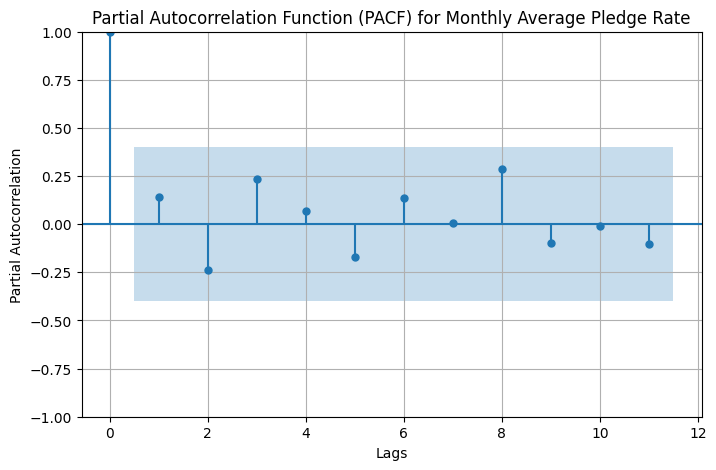

In [77]:
ks4 = ks2[ks2['state'] == 'successful']
ks5 = ks4.groupby(['month_year'])['pledge_prop'].mean()
plot_lag(ks5)

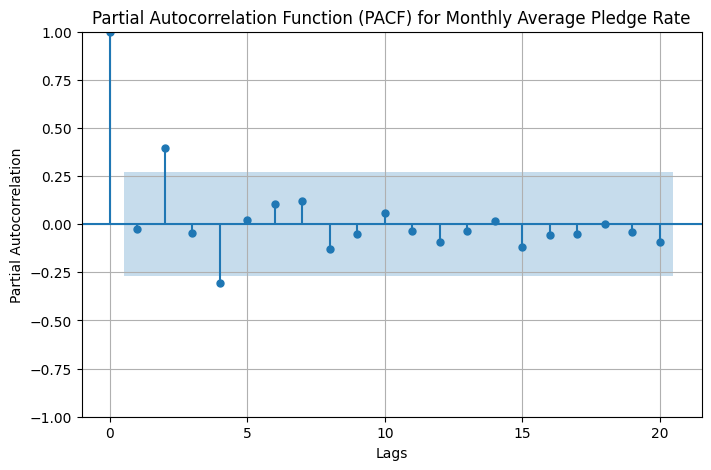

In [76]:
def plot_lag(df):
  df.index = pd.PeriodIndex(df.index, freq='M')
  df.index = df.index.to_timestamp()

  # Generate PACF plot
  plt.figure(figsize=(8, 5))
  # Limit lags to a safe maximum: min(20, (sample_size // 2) - 1)
  plot_pacf(df, lags=min(20, (len(df) // 2) - 1), ax=plt.gca())
  plt.title('Partial Autocorrelation Function (PACF) for Monthly Average Pledge Rate')
  plt.xlabel('Lags')
  plt.ylabel('Partial Autocorrelation')
  plt.grid(True)
  plt.show()
df_Canada_monthly = df_cleaned[df_cleaned['country'] == 'Canada'].groupby('month_year')['usd_goal_real'].mean()
plot_lag(df_Canada_monthly)


# **Boxplot**

In [34]:
df_Art_Publishing = df_cleaned[df_cleaned['main_category'].isin(['Art','Publishing'])].groupby(['month_year','main_category'])['usd_pledged_real'].sum().copy().reset_index()
df_Art_Publishing

,month_year,main_category,usd_pledged_real
0,2009-04,Art,35.00
1,2009-04,Publishing,1313.00
2,2009-05,Art,7438.00
3,2009-05,Publishing,3052.00
4,2009-06,Art,5701.01
...,...,...,...
209,2017-12,Publishing,737035.82
210,2018-01,Art,5590.81
211,2018-01,Publishing,5750.81
212,2070-01,Art,0.00


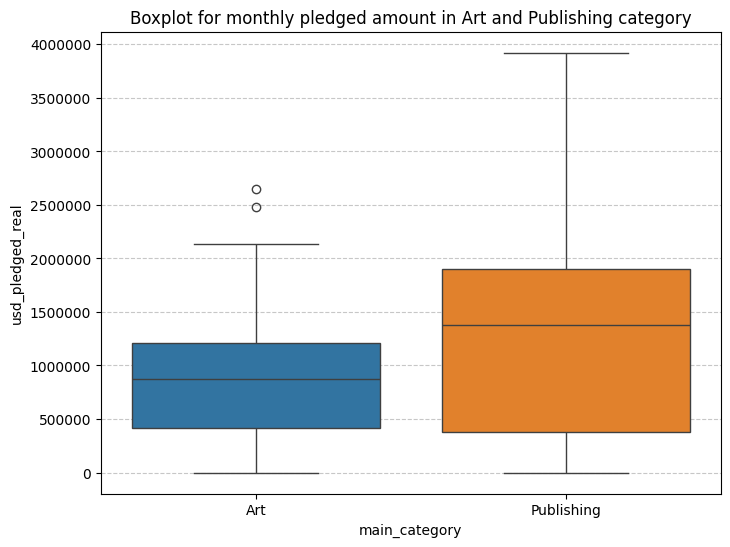

In [35]:
plt.figure(figsize = (8,6))
sns.boxplot(data = df_Art_Publishing,
            x = 'main_category',
            y = 'usd_pledged_real',
            hue = 'main_category')
plt.title('Boxplot for monthly pledged amount in Art and Publishing category')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
import matplotlib.ticker as ticker

# This will turn off scientific notation
plt.ticklabel_format(style='plain', axis='y')
plt.show()

The boxplot shows that Publishing has higher monthly pledged amount median than Art. While Art has a few outliers, publishing is more spread out with 75th quartile around 2M and no outliers.

# **Violin Chart**

In [36]:
df_Dance = df_cleaned[df_cleaned['main_category'] == 'Dance'].groupby(['month_year','category'])['usd_pledged_real'].sum().copy().reset_index()
df_Dance

,month_year,category,usd_pledged_real
0,2009-09,Dance,6935.37
1,2009-10,Dance,217.12
2,2009-11,Dance,0.00
3,2009-12,Dance,14626.00
4,2010-01,Dance,7387.00
...,...,...,...
269,2017-11,Workshops,1274.00
270,2017-12,Dance,1263.24
271,2017-12,Performances,27782.82
272,2017-12,Spaces,225.00


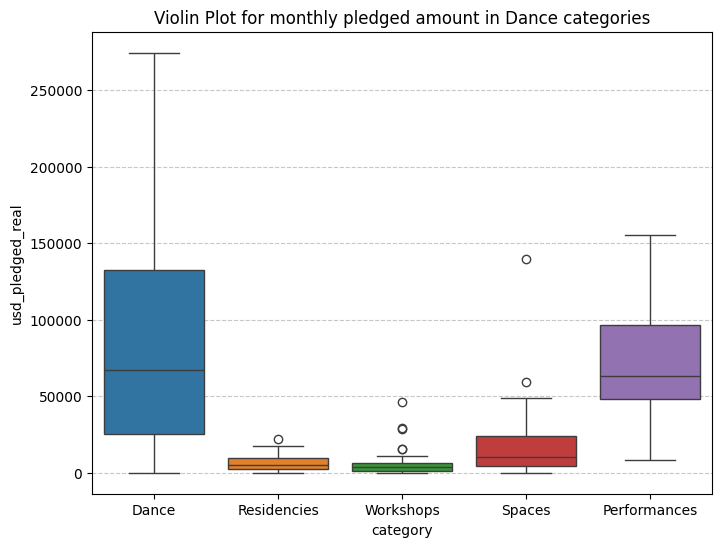

In [37]:
plt.figure(figsize = (8,6))
sns.boxplot(data = df_Dance,
            x= 'category',
            y = 'usd_pledged_real',
            hue = 'category')
plt.title('Violin Plot for monthly pledged amount in Dance categories')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
import matplotlib.ticker as ticker
# This will turn off scientific notation
plt.ticklabel_format(style='plain', axis='y')
plt.show()

Within dance categories, Dance and Performances has higher median around 60k pledge amount per month, dance has much higher spread. Workshop and Residencies have much lower spread, mostly under 50k but with a few outliers. Spaces is the middle with a medium spread from 0-5k and one really significant outlier

# **Histogram**

In [38]:
df_backers = df_cleaned[df_cleaned['main_category'].isin(['Music','Film & Video'])].groupby(['month_year','main_category'])['backers'].sum().copy().reset_index()
df_backers

,month_year,main_category,backers
0,2009-04,Film & Video,32
1,2009-04,Music,2
2,2009-05,Film & Video,438
3,2009-05,Music,1420
4,2009-06,Film & Video,256
...,...,...,...
209,2017-12,Music,4895
210,2018-01,Film & Video,25
211,2018-01,Music,183
212,2070-01,Film & Video,0


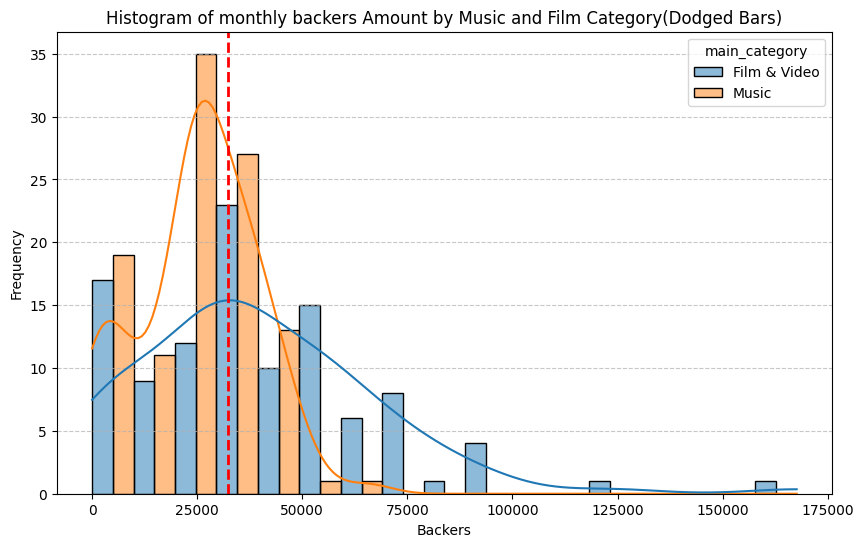

In [39]:
plt.figure(figsize=(10,6))
backer_hist=sns.histplot(x='backers',
             hue='main_category',
             data=df_backers,
             binwidth=10000,
             edgecolor='black',
             color='blue',
             kde=True,
             multiple='dodge') # dodge the histogram bars
plt.title('Histogram of monthly backers Amount by Music and Film Category(Dodged Bars)')
plt.xlabel('Backers')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
mean_backers = df_backers['backers'].mean()
backer_hist.axvline(x=mean_backers, color='red', linestyle='--', linewidth=2) # Add a vertical line at the mean
plt.show()

Music category has most months with backers around 25000-50000 and the whole distribution is very tight, with max lower than 75000. While Film's backers distribution is more spread out, with a lower peak and a few months more than 75000 backers. It's also worth attention that there are many months where both categories have very few backers, on the very left of x-axis. In general film and music category has unstable monthly backers, while film category has higher potential for greater amount of backers per month.

# **Pyramid Chart**

([<matplotlib.axis.XTick at 0x792894917290>,
 [Text(-40.0, 0, '40'),
  Text(-30.0, 0, '30'),
  Text(-20.0, 0, '20'),
  Text(-10.0, 0, '10'),
  Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30')])

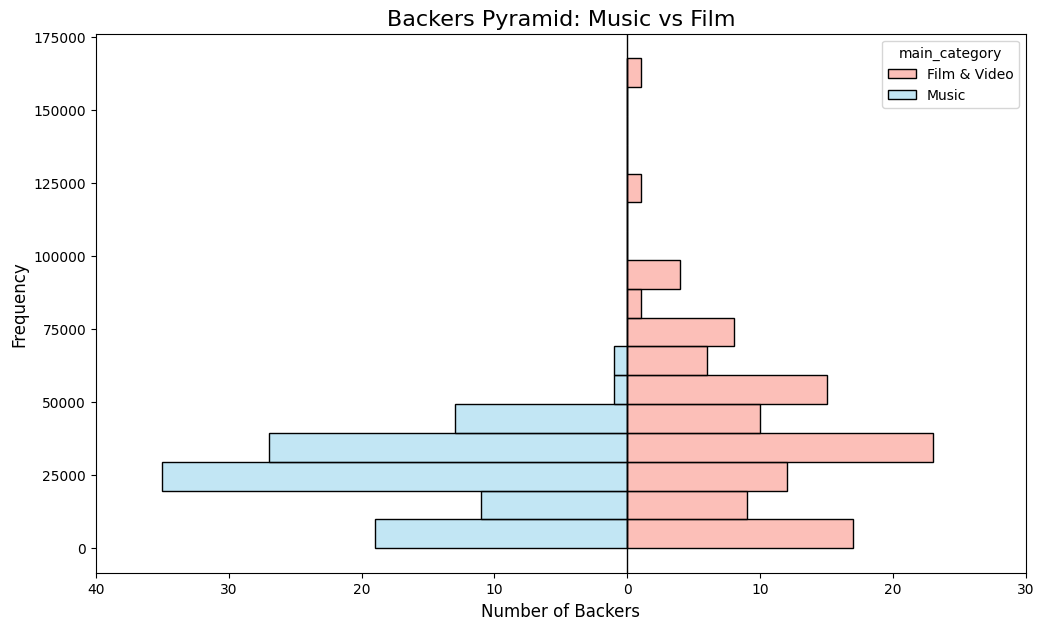

In [40]:
df_backers['weight'] = df_backers['main_category'] \
.map({'Music':-1, 'Film & Video':1})

plt.figure(figsize=(12, 7))

# Create the pyramid chart using histplot
sns.histplot(
    data=df_backers,
    y='backers',      # bins go here
    weights='weight',          # signed counts
    hue='main_category',
    binwidth=10000,
    stat='count',
    palette={'Music': 'skyblue', 'Film & Video': 'salmon'},
)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Number of Backers', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Backers Pyramid: Music vs Film', fontsize=16)

# Get current x-axis tick locations and labels
locs, labels = plt.xticks()
# Update labels to show absolute values
plt.xticks(locs, [str(int(abs(loc))) for loc in locs])

# **Line Chart**

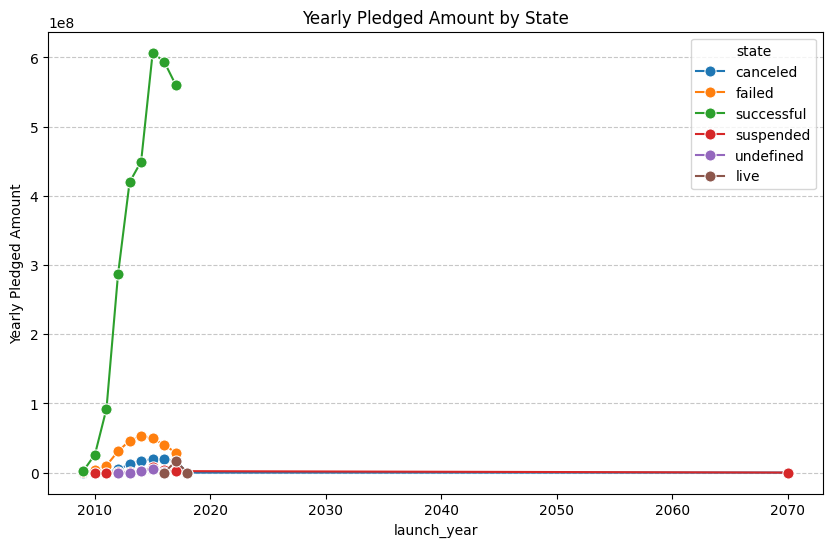

In [41]:
df_successful = df_cleaned.groupby(['launched_year','state']).agg({
    'usd_pledged_real':'sum',
    'usd_goal_real':'sum'

}).copy().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(x='launched_year',
             y='usd_pledged_real',
             hue='state',
             data=df_successful,
             marker='o',
             markersize=8,
             errorbar=None) # Added errorbar=None to remove CI shade
plt.title('Yearly Pledged Amount by State')
plt.xlabel('launch_year')
plt.ylabel('Yearly Pledged Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The line char shows that different state show different pattern across years. Successful projects' pledged amount have been increasing till 2015, and decreased since then. The failed amount followed a similar trend but decreased earlier in 2014. In 2014-2015 successful projects and failed projects move in different directions in pledged amount. This might be caused by bigger quality difference between projects in that period.

# **Count Plot**

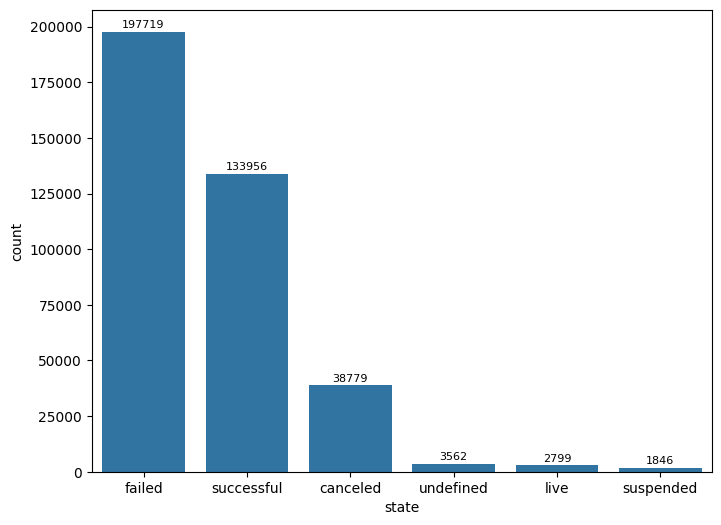

In [42]:
plt.figure(figsize = (8,6))
ax = sns.countplot(data = df_cleaned,
              x = 'state',
              order=df_cleaned['state'].value_counts(ascending=False).index,
              dodge = False)
for p in ax.patches:
  ax.annotate(f'{p.get_height():.0f}', # Changed to .0f for integer formatting
              (p.get_x() + p.get_width()/2, p.get_height()), #set label location
              ha='center', va='center', #horizontal and vertical alignment
              xytext=(0,5), # offset points
              textcoords = 'offset points', # use point system for offset
              fontsize=8,
              color='black'
              )

The bar chart shows that majority of projects are either failed, successful or canceled. Failed projects is 1.5 times more than successful projects. The acmount of cancelled projects is also significant.

Text(0.5, 1.0, 'Bar Plot: Pledge Amount for different states with High, Medium and Low goal')

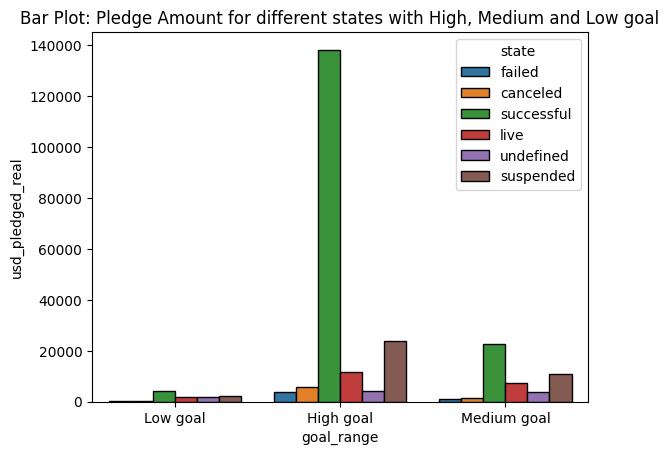

In [43]:
sns.barplot(data=df_cleaned,
            x='goal_range',
            y='usd_pledged_real',
            hue = 'state',
            edgecolor = 'black',
            dodge = True,
            errorbar = None)
plt.title('Bar Plot: Pledge Amount for different states with High, Medium and Low goal')

For high goal projects, while successful projects get incredibly high pledge amount, the failure projects just get as much as low/medium goal project does, showing the high goal strategy is All or Nothing. Also the amount of suspended projects is also decent.

/tmp/ipykernel_8027/1908522481.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


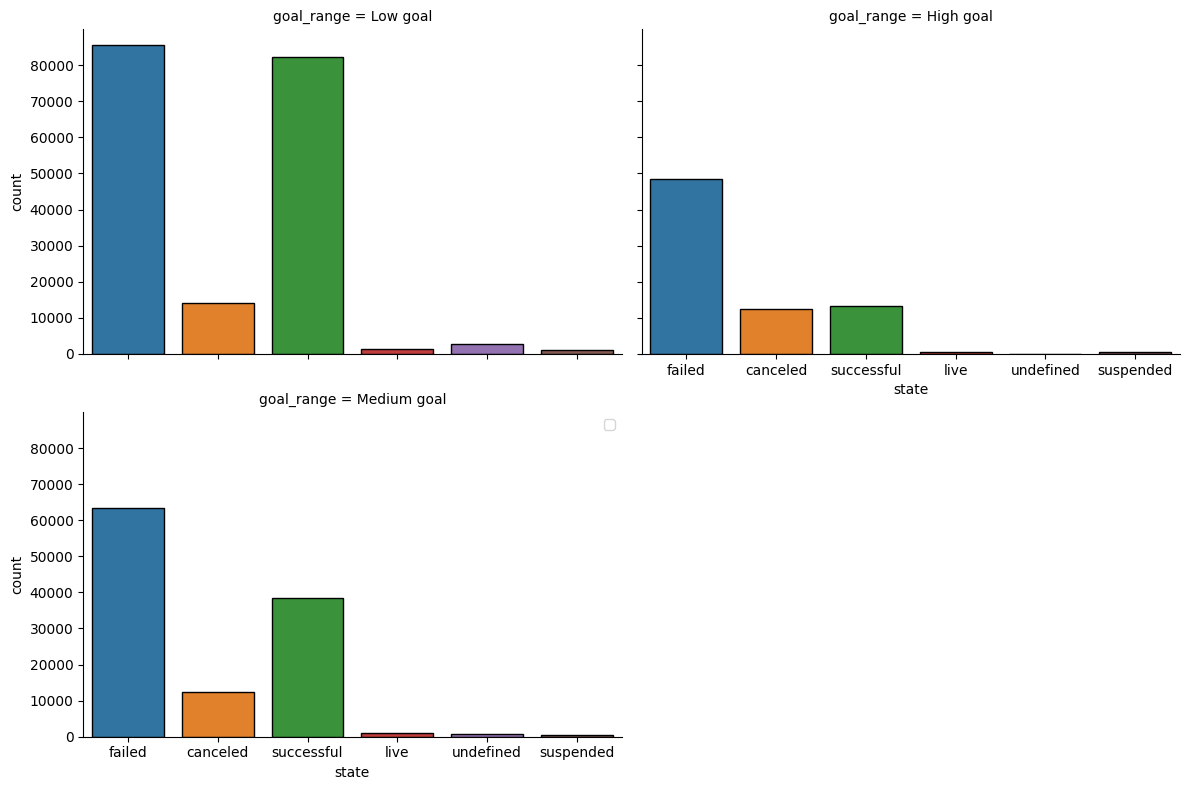

In [44]:
sns.catplot(data=df_cleaned,
            x='state',
            col='goal_range',
            hue='state',
            col_wrap=2,
            kind='count',
            dodge=False,
            height=4,
            aspect=1.5,
            edgecolor = 'black')
plt.legend()

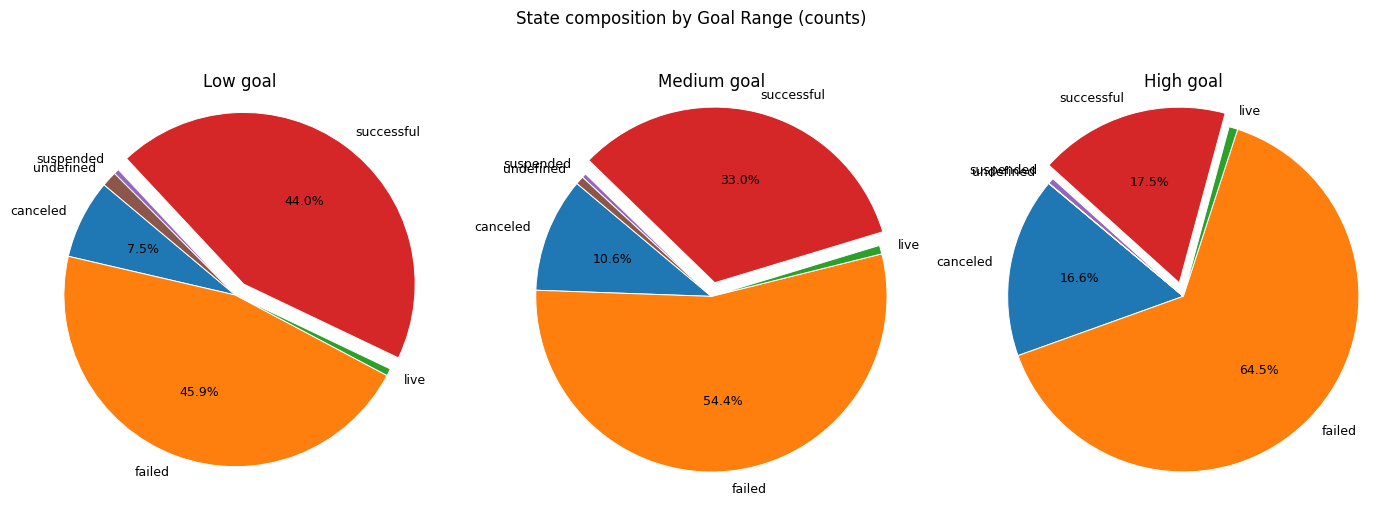

In [45]:
ct = pd.crosstab(df_cleaned['goal_range'], df_cleaned['state'])
order = ['Low goal', 'Medium goal', 'High goal']
ct = ct.reindex(order).fillna(0)

# 2) Build pies
fig, axes = plt.subplots(1, 3, figsize=(14,5))
for ax, (goal, row) in zip(axes, ct.iterrows()):
    labels = row.index.tolist()
    sizes  = row.values.astype(float)
    # optional: hide zero-value slices
    labels = [lab for lab, sz in zip(labels, sizes) if sz > 0]
    sizes  = [sz for sz in sizes if sz > 0]

    # explode only the 'successful' wedge for emphasis (if present)
    explode = [0.08 if lab == 'successful' else 0 for lab in labels]

    ax.pie(sizes,
           labels=labels,
           autopct=lambda p: f'{p:.1f}%' if p > 2 else '',  # hide tiny pct labels
           startangle=140,
           explode=explode,
           wedgeprops=dict(edgecolor='white', linewidth=0.7),
           textprops=dict(fontsize=9))
    ax.set_title(goal)
    ax.axis('equal')  # equal aspect -> circle

plt.suptitle('State composition by Goal Range (counts)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

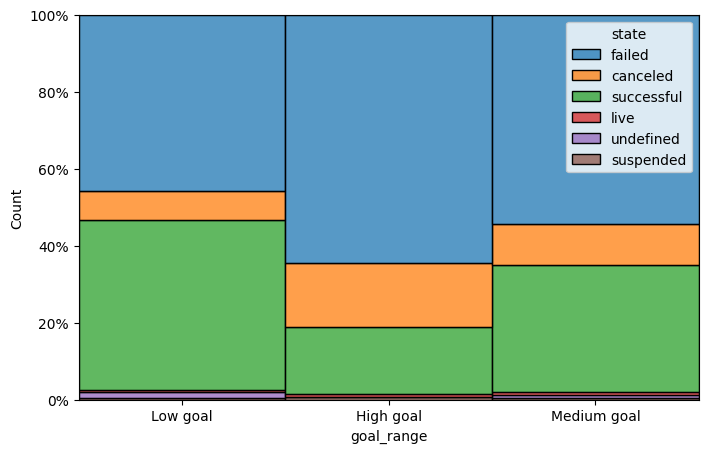

In [46]:
plt.figure(figsize=(8, 5))

ax = sns.histplot(data=df_cleaned, x='goal_range',
             binwidth=5,
             hue='state',
             multiple='fill')
plt.ticklabel_format(style='plain', axis='y')
import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

The pie charts and the histogram shows how successful rates vary in different goral ranges. High goal projects have around 20% success rate, while low goal projects have more than 40%. It's worth noticing the risks when setting up a high goal.

# **Two_Axis**

In [47]:
df_backer_pledged = df_cleaned.groupby(['launched_year']).agg({
    'usd_pledged_real' : 'mean',
    'backers' : 'sum'
})
df_backer_pledged

,usd_pledged_real,backers
launched_year,,
2009,2141.084357,43758
2010,2800.482267,406875
2011,3954.438151,1396473
2012,7833.156323,4343786
2013,10669.566477,6292568
2014,7744.495587,6194576
2015,8894.549461,7512058
2016,11488.352415,7148604
2017,11954.014957,6653360


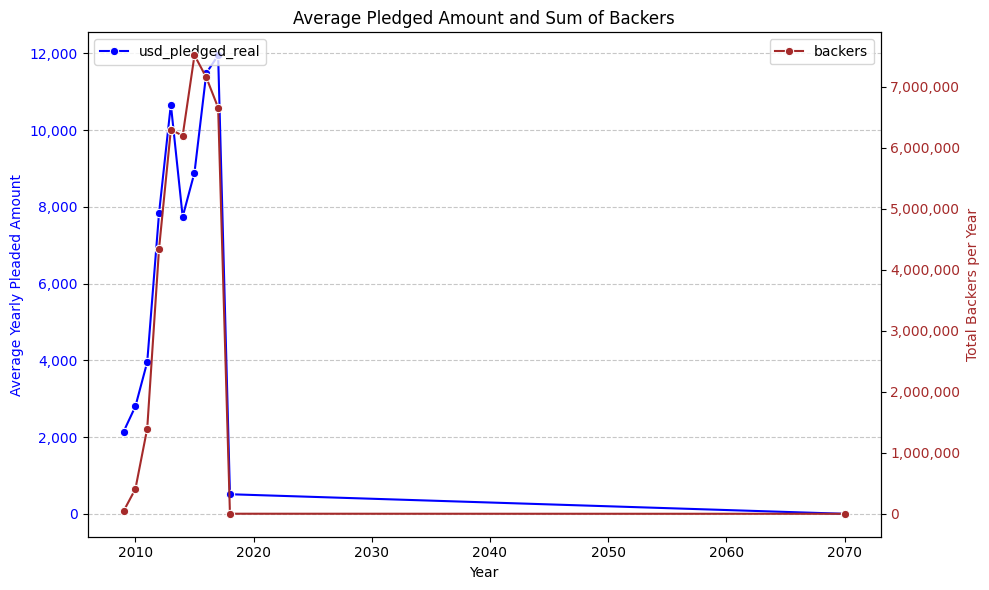

In [48]:
fig, ax1 = plt.subplots(figsize=(10,6))
# plot dep delay
sns.lineplot(x='launched_year',
             y='usd_pledged_real',
             data=df_backer_pledged,
             marker='o',
             ax=ax1,
             color='blue',
             label='usd_pledged_real')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Yearly Pleaded Amount', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# generate twin x for count line
ax2=ax1.twinx()
sns.lineplot(x='launched_year',
             y='backers',
             data=df_backer_pledged,
             marker='o',
             ax=ax2,
             color='brown',
             label='backers')
ax2.set_ylabel('Total Backers per Year', color='brown')
ax2.tick_params(axis='y', labelcolor='brown')

plt.title('Average Pledged Amount and Sum of Backers')

# Place legends separately on each axis
ax1.legend(loc='upper left') # Legend for Avg. Departure Delay
ax2.legend(loc='upper right') # Legend for Count of flights
#Digits
plt.ticklabel_format(style='plain', axis='y')
import matplotlib.ticker as mtick
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout() # Adjust layout to prevent labels from being cut off

plt.show()

This visual shows a change of correlation between yearly average pleadged amount vs number of backers. Before 2015, there is a high correlation, indicating growth of the platform and stable contribution per backer. From 2015-2017, backers started to decrease while pleadged amount stay increasing. This indicates there is less backers but the remaining backers are contributing more to the projects. If we can figure out the reason behind backer decrease, there is great growth opportunity.

# **Scatterplot and FacetGrid**

In [49]:
df_goal_pledge = df_cleaned.groupby(['month_year','state']).agg({
    'usd_pledged_real':'sum',
    'usd_goal_real':'sum'
}).copy().reset_index()
df_goal_pledge

,month_year,state,usd_pledged_real,usd_goal_real
0,2009-04,canceled,0.00,500.00
1,2009-04,failed,1171.00,84340.00
2,2009-04,successful,27758.66,22819.00
3,2009-05,canceled,2607.00,154900.00
4,2009-05,failed,6935.77,124379.00
...,...,...,...,...
437,2017-12,suspended,25050.47,264799.40
438,2018-01,canceled,77.75,4130.33
439,2018-01,live,63145.04,1718587.73
440,2070-01,canceled,0.00,35200.00


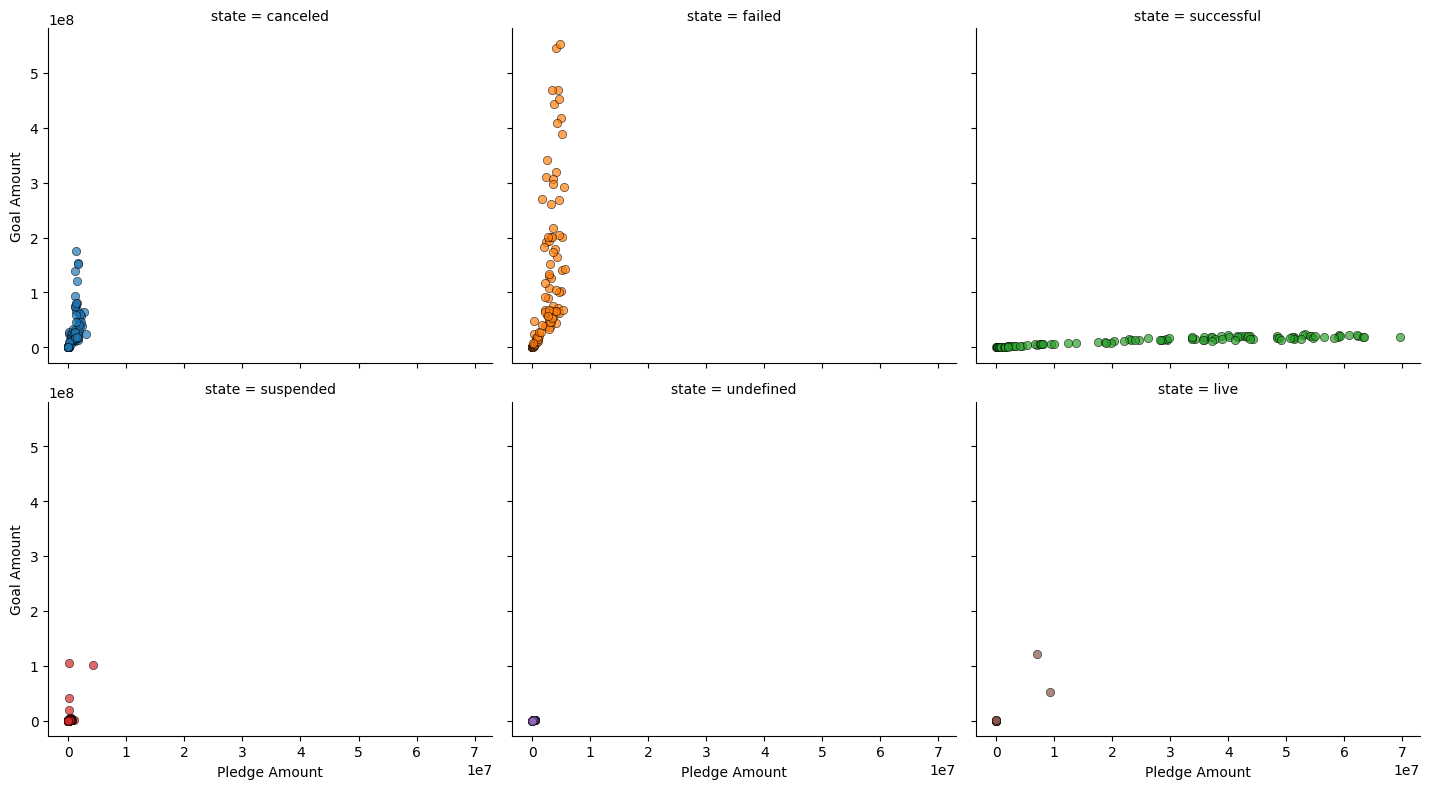

In [50]:

state_grid=sns.FacetGrid(df_goal_pledge,
                           col='state',
                           hue='state',
                           col_wrap=3,
                           height=4,
                           aspect=1.2)
state_grid.map_dataframe(sns.scatterplot,
                           x='usd_pledged_real',
                           y='usd_goal_real',
                           alpha=0.7,
                           edgecolor='black')
state_grid.set_axis_labels('Pledge Amount', 'Goal Amount')

The scatterplots show that for cancelled and failed projects, the pledged amounts are much smaller than the goal amounts. For successful projects, the pledged amount is much bigger than goal amount. This indicates that only for sucessful projects, higher goals would lead to higher pledge amount. Backers have similar standards to contribute to a great project and refuse a failing project.

# **Diverging Bar Chart**

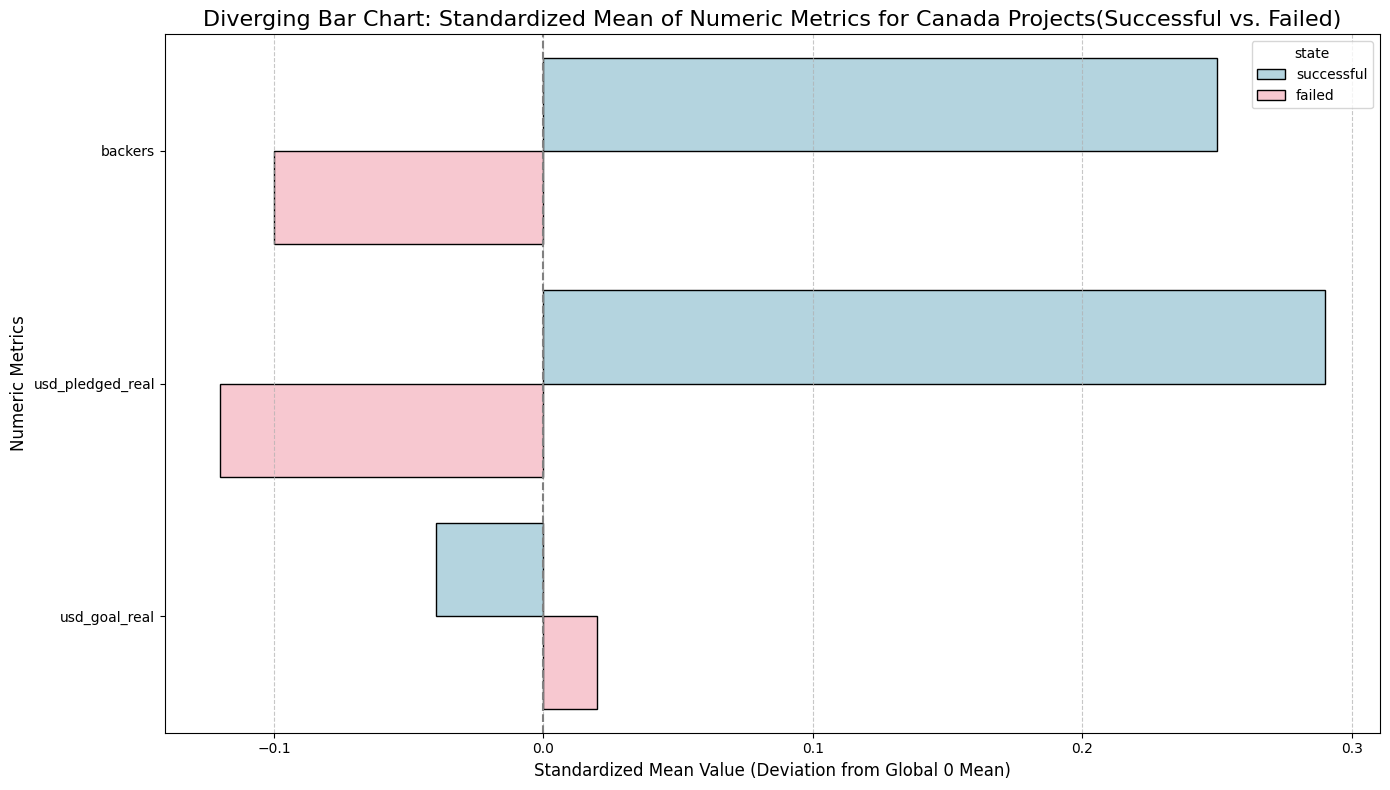

In [51]:


from sklearn.preprocessing import StandardScaler # for standardization

# Create a copy to avoid modifying the original df_pop directly for this operation
df_canada_normalized_features = df_cleaned[df_cleaned['country']=='Canada'].copy()

# Identify numeric columns (excluding 'track_popularity' and 'cat')
numeric_features = [
    'backers', 'usd_pledged_real', 'usd_goal_real'
]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply normalization to each numeric feature across the entire DataFrame (regardless of cat)
df_canada_normalized_features[numeric_features] = scaler.fit_transform(df_canada_normalized_features[numeric_features])

# Now, calculate the mean of these globally normalized features grouped by 'cat'
# This will be our pop_feature equivalent for normalized data
df_for_diverging = df_canada_normalized_features.groupby('state')[numeric_features].mean().round(2).T

# In this case, since data is standardized globally, the overall mean is approximately 0. We can directly use the 'high' and 'low' standardized means as their deviations from 0.

# Reset index to make 'feature' a regular column for plotting
df_for_diverging = df_for_diverging.reset_index().rename(columns={'index': 'metrics'})

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted_deviations = df_for_diverging.melt(
    id_vars=['metrics'],
    value_vars=['successful', 'failed'],
    var_name='state',
    value_name='deviation'
)

plt.figure(figsize=(14, 8)) # Adjust figure size for better readability

# Create the diverging bar chart
sns.barplot(
    data=df_melted_deviations,
    x='deviation',       # Deviation on the x-axis
    y='metrics',         # Features on the y-axis
    hue='state', # Differentiate 'high' and 'low' deviations
    palette={'successful': 'lightblue', 'failed': 'pink'},
    errorbar=None,       # No error bars as we're plotting calculated means
    dodge=True,           # Display bars for 'high' and 'low' side-by-side
    edgecolor='black'
)

# Add a vertical line at x=0 to emphasize deviations (which is now the global mean)
plt.axvline(0, color='gray', linestyle='--', linewidth=1.5)

plt.title('Diverging Bar Chart: Standardized Mean of Numeric Metrics for Canada Projects(Successful vs. Failed)', fontsize=16) # Updated title
plt.xlabel('Standardized Mean Value (Deviation from Global 0 Mean)', fontsize=12) # Updated label
plt.ylabel('Numeric Metrics', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# plt.legend(title='Popularity Category', bbox_to_anchor=(1.05, 1), loc='upper left') #if you wish to position the ledgend out of the chart
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




This diverging barchart shows that in Canada, the comparison between successful and failed projects show siginificant differences in numeric metrics. Successful projects have much more backers and pledged amount, which is what I expected. But for goal amount, failed projects in general have more than average. This is showing for projects in Canada, a modest, achivable goal is key to success.

# **Moving Average**

In [52]:
def moving_average(df,time,col,i,j,k):
  plt.figure(figsize=(12,8))
  for window_size in range(i, j, k):
    df[col+f'MA{window_size}'] = df[col].rolling(window=window_size, min_periods=window_size).mean().shift(1)
    # Use a temporary variable for MAD calculation within the loop
    current_mad = (df[col] - df[col+f'MA{window_size}']).abs().mean()
    print(f"Mean Absolute Deviation (MAD) of the {window_size}-Year Moving Average forecast: {current_mad}")
    sns.lineplot(data=df, x=time, y=col+f'MA{window_size}', linestyle='--', label=f'{window_size}-Year Moving Average Forecast', errorbar=None)
  sns.lineplot(data=df, x='month_year', y=col, errorbar=None, label='Actual'+col)
  plt.show()

In [53]:
df_ma = df_cleaned[df_cleaned['country']=='United Kingdom'].groupby('month_year')['usd_pledged_real'].sum().copy().reset_index()
df_ma

,month_year,usd_pledged_real
0,2012-10,1184744.92
1,2012-11,5523063.67
2,2012-12,1076836.72
3,2013-01,2514588.89
4,2013-02,3686512.55
...,...,...
59,2017-09,5160758.47
60,2017-10,4183324.14
61,2017-11,5043444.29
62,2017-12,1184693.46


Mean Absolute Deviation (MAD) of the 1-Year Moving Average forecast: 1566516.0957142857
Mean Absolute Deviation (MAD) of the 3-Year Moving Average forecast: 1468050.1136612021
Mean Absolute Deviation (MAD) of the 5-Year Moving Average forecast: 1330735.0706440678
Mean Absolute Deviation (MAD) of the 7-Year Moving Average forecast: 1321157.9431578945
Mean Absolute Deviation (MAD) of the 9-Year Moving Average forecast: 1396226.1041414142
Mean Absolute Deviation (MAD) of the 11-Year Moving Average forecast: 1405674.5353859349
Mean Absolute Deviation (MAD) of the 13-Year Moving Average forecast: 1371375.6981749623
Mean Absolute Deviation (MAD) of the 15-Year Moving Average forecast: 1388333.5218503403
Mean Absolute Deviation (MAD) of the 17-Year Moving Average forecast: 1421585.0020275344
Mean Absolute Deviation (MAD) of the 19-Year Moving Average forecast: 1404383.82871345


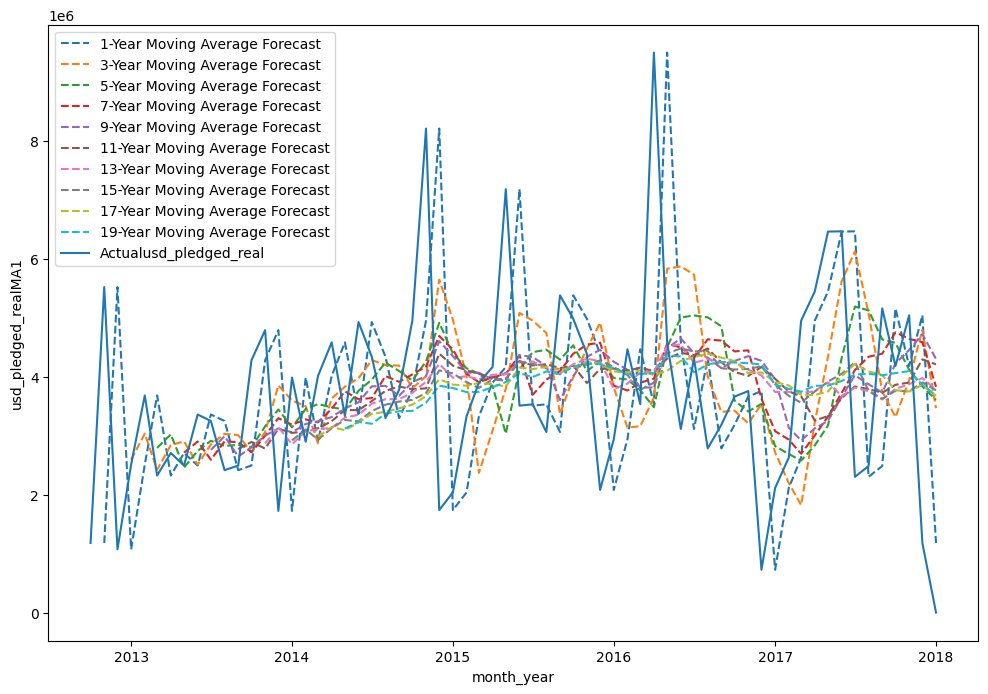

In [54]:
df_ma['month_year'] = df_ma['month_year'].dt.to_timestamp()
moving_average(df_ma,'month_year','usd_pledged_real',1,20,2)
SD = 1.25*1330733.9992881357

According to the chart and the output, MA5 is the best period to use rolling average to predict pledged amount in United Kingdom

# **Auto-Regression**

In [55]:
from statsmodels.graphics.tsaplots import plot_pacf
def plot_lag(df):
  df.index = pd.PeriodIndex(df.index, freq='M')
  df.index = df.index.to_timestamp()

  # Generate PACF plot
  plt.figure(figsize=(8, 5))
  # Limit lags to a safe maximum: min(20, (sample_size // 2) - 1)
  plot_pacf(df, lags=min(20, (len(df) // 2) - 1), ax=plt.gca())
  plt.title('Partial Autocorrelation Function (PACF) for Monthly Mean Loudness')
  plt.xlabel('Lags')
  plt.ylabel('Partial Autocorrelation')
  plt.grid(True)
  plt.show()

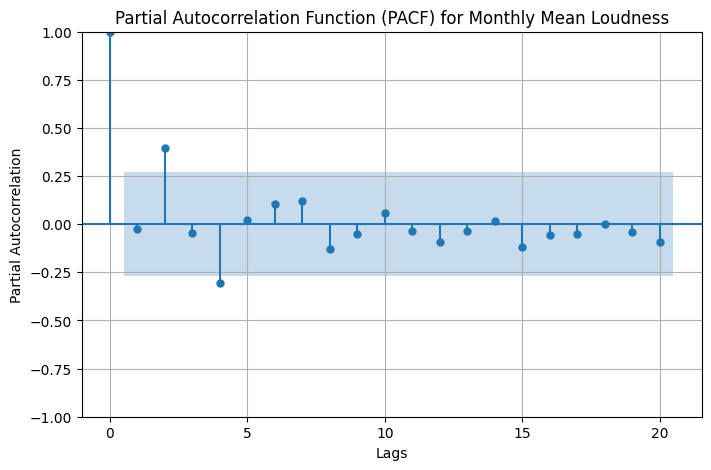

In [56]:
df_Canada_monthly = df_cleaned[df_cleaned['country'] == 'Canada'].groupby('month_year')['usd_goal_real'].mean()
plot_lag(df_Canada_monthly)

In [57]:
def auto_reg(i,df):
  from statsmodels.tsa.ar_model import AutoReg
  df.index = pd.to_datetime(df.index)
  df = df.asfreq('MS')
  lags_value = i # Define lags_value

  # Fit an AR model using order=2 based on previous PACF plot inspection
  model = AutoReg(df, lags=lags_value)
  model_fit = model.fit()

  # Plot actual vs. fitted values
  plt.figure(figsize=(12, 6))
  # Plot actuals, aligning to the index of the non-NaN fitted values
  sns.lineplot(x=model_fit.fittedvalues.index, y=df.loc[model_fit.fittedvalues.index], label='Actual', marker='o')
  # Plot fitted values
  sns.lineplot(x=model_fit.fittedvalues.index, y=model_fit.fittedvalues, label=f'Fitted(AR({lags_value}))', linestyle='--')
  plt.legend()
  plt.grid(True)
  plt.show()

  # Display model summary
  print(model_fit.summary())

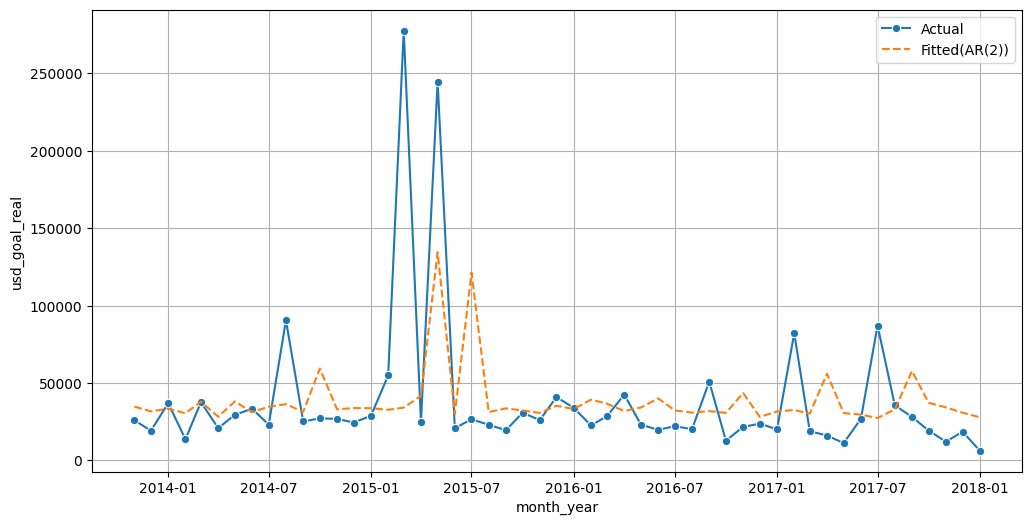

                            AutoReg Model Results                             
Dep. Variable:          usd_goal_real   No. Observations:                   53
Model:                     AutoReg(2)   Log Likelihood                -617.858
Method:               Conditional MLE   S.D. of innovations          44175.218
Date:                Thu, 12 Mar 2026   AIC                           1243.715
Time:                        20:00:46   BIC                           1251.443
Sample:                    11-01-2013   HQIC                          1246.668
                         - 01-01-2018                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const             2.325e+04   9470.282      2.455      0.014    4687.954    4.18e+04
usd_goal_real.L1    -0.0128      0.129     -0.099      0.921      -0.265       0.240
usd_goal_real.L2     0.4019 

In [58]:
auto_reg(2,df_Canada_monthly)

The coefficient of AR1 is not significant and AR2 is significant. The coefficient for AR2 is 0.4, showing that 40% of mean pledged goal two months ago contributes to the current mean. Both roots are greater than 1, showing this model is stantionary.

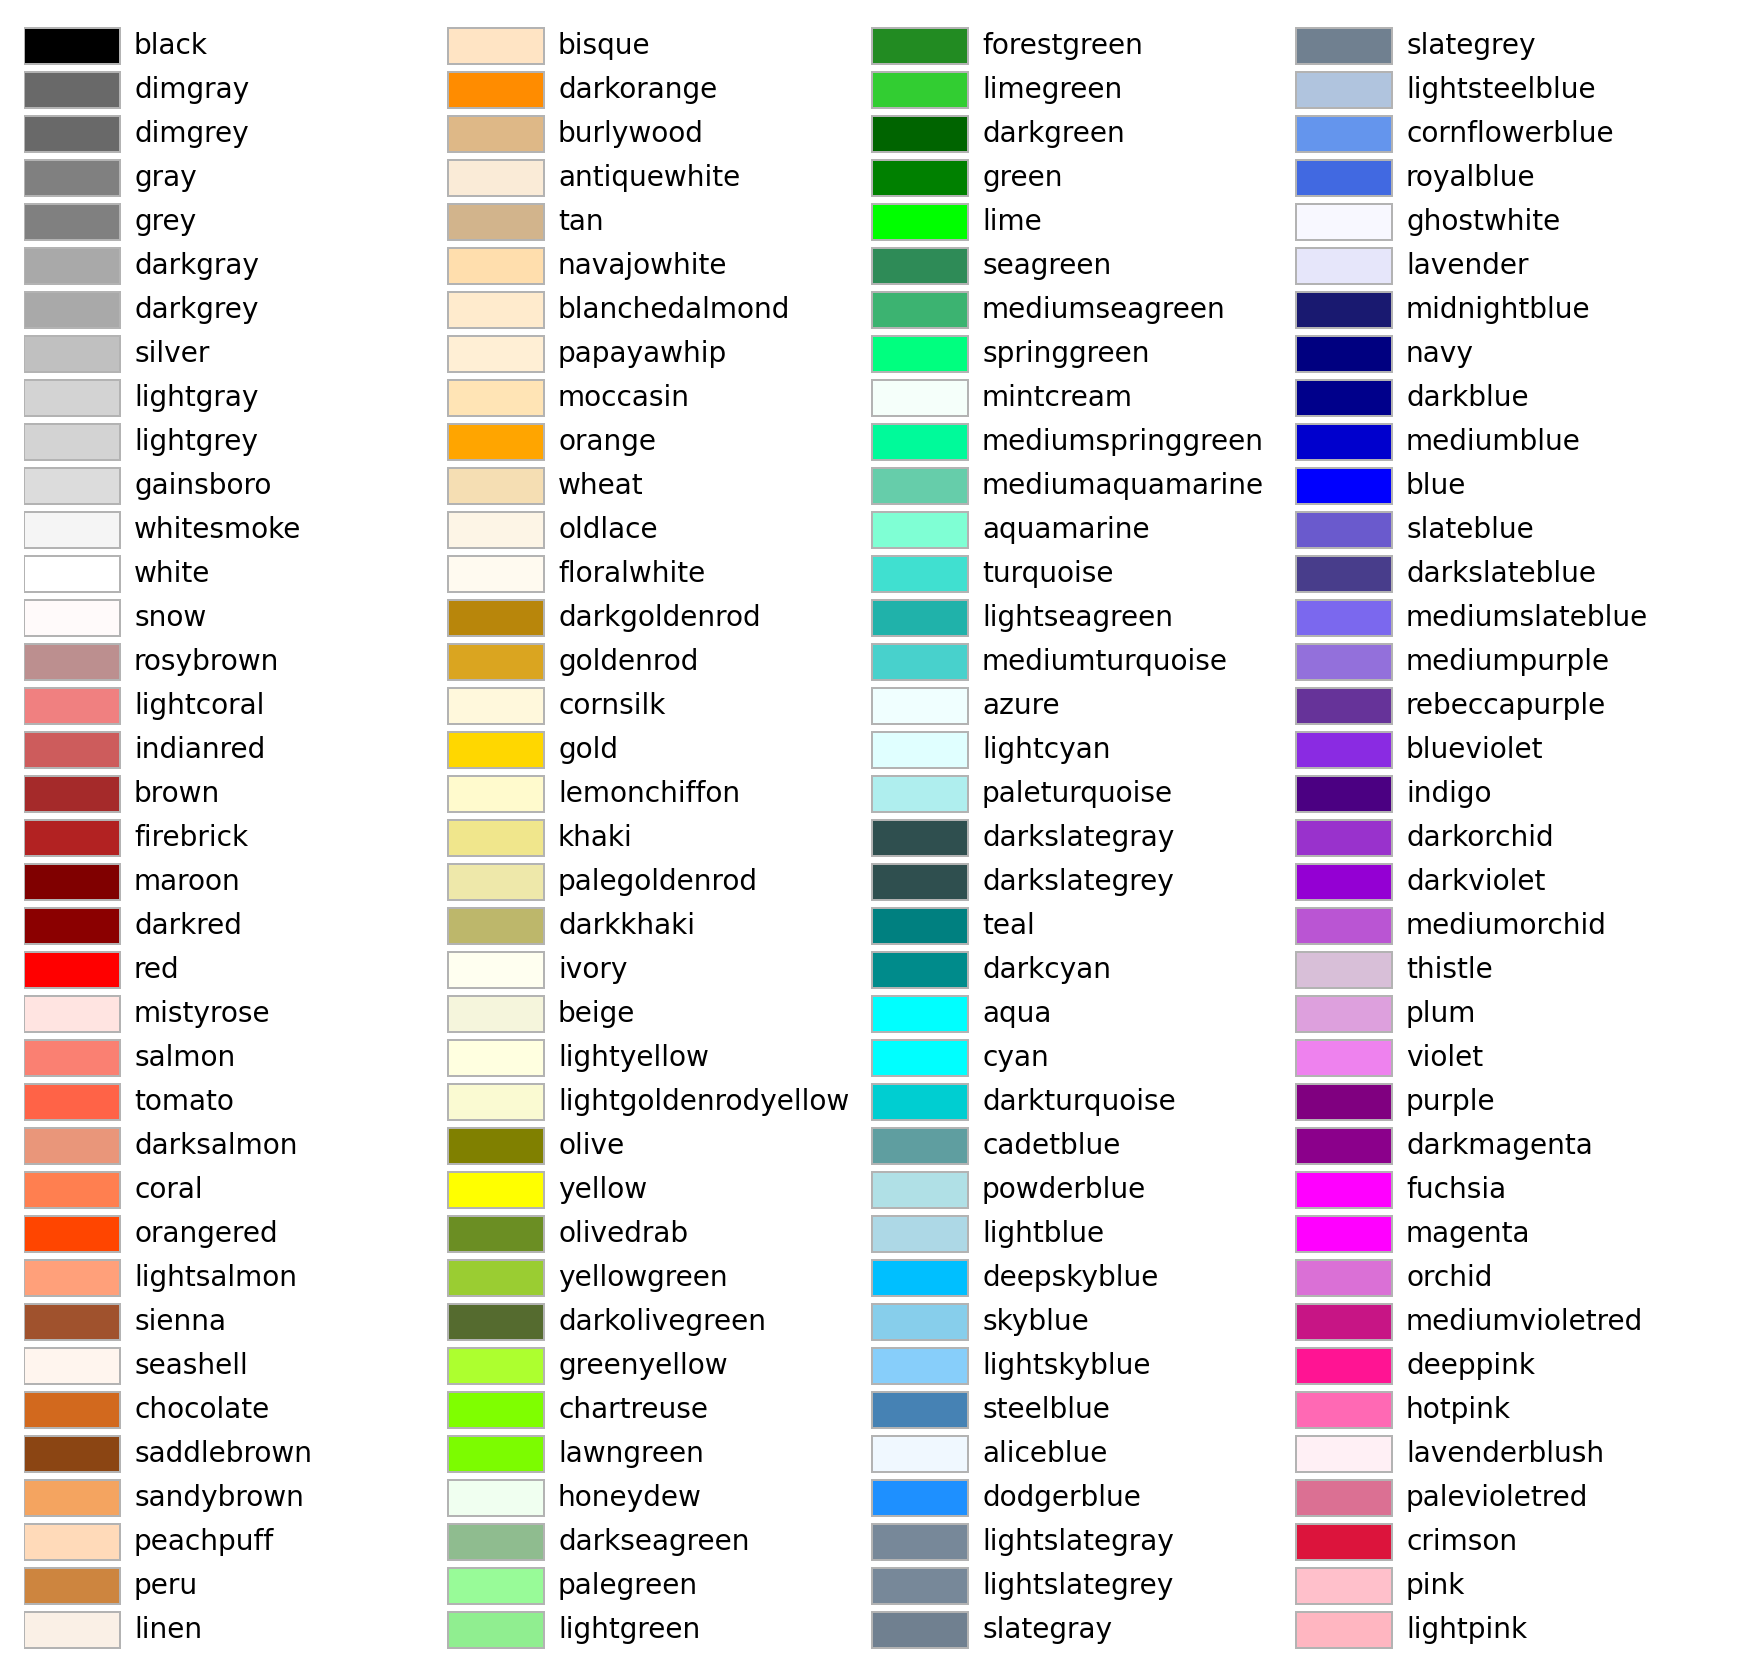